# Titanic Survival Analysis - Feature Engineering

In [1]:
# Import required libraries
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
pd.set_option("display.max_columns", None)

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")

from scipy.stats import skew

## Load Cleaned Dataset

The feature engineering stage builds upon the cleaned dataset generated during data wrangling and preprocessing. This notebook focuses on creating, evaluating, and preparing predictive features for downstream modeling.

In [2]:
df = pd.read_csv("../data/processed/titanic_cleaned.csv")

In [3]:
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (891, 9)


In [4]:
print("First 5 rows: ")
df.head()

First 5 rows: 


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S


## Dataset Validation

A brief validation is performed to confirm dataset integrity before feature creation.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       891 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Fare      891 non-null    float64
 8   Embarked  891 non-null    str    
dtypes: float64(2), int64(4), str(3)
memory usage: 62.8 KB


In [6]:
print(f"Total Null Values: \n{df.isnull().sum()}")

Total Null Values: 
Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [7]:
print("Descriptive Statistics:")

df.describe()

Descriptive Statistics:


,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Feature Engineering Strategy

Feature creation is guided by findings from the exploratory analysis.

Planned feature groups:

- Family structure features
- Demographic features
- Fare-based transformations
- Age-based representations

Each engineered feature is intended to capture information not directly represented by the original variables.

### Family Size

Family structure exhibited a meaningful relationship with survival outcomes. A consolidated family size feature is created from sibling/spouse and parent/child counts.

In [8]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [33]:
# validation 

df["FamilySize"].value_counts().sort_index()

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

### Solo Travel Indicator

A binary indicator is created to distinguish passengers traveling alone from those traveling with family members.

In [10]:
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

In [11]:
# validation

df["IsAlone"].value_counts()

IsAlone
1    537
0    354
Name: count, dtype: int64

### Demographic Features

Passenger titles provide additional demographic information that may not be fully captured by age or gender alone.

In [12]:
df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.")

In [13]:
df["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [14]:
# handling rare titles

rare_titles = [
    "Dr",
    "Rev",
    "Major",
    "Col",
    "Don",
    "Lady",
    "Sir",
    "Capt",
    "the Countess",
    "Jonkheer"
]

df["Title"] = df["Title"].replace(rare_titles, "Rare")
df["Title"] = df["Title"].replace({
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
})

In [15]:
df["Title"].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

In [16]:
# drop Name

df = df.drop(columns = "Name")

### Fare-Based Features

Ticket fare exhibited a right-skewed distribution. A logarithmic transformation is applied to reduce skewness while preserving ordering relationships.

In [17]:
df['LogFare'] = np.log1p(df['Fare'])

In [18]:
print(f"Fare Skewness: {skew(df['Fare']):.2f}")
print(f"LogFare Skewness: {skew(df['LogFare']):.2f}")

Fare Skewness: 4.78
LogFare Skewness: 0.39


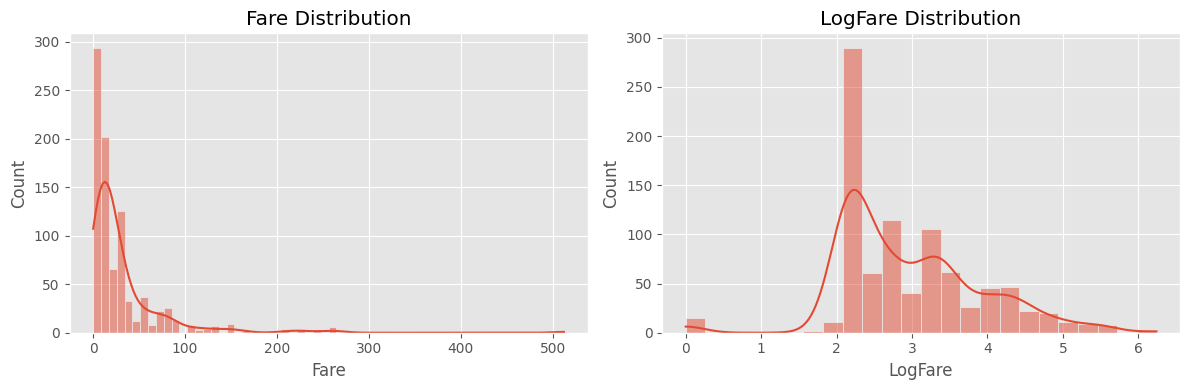

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["Fare"], kde=True, ax=axes[0])
axes[0].set_title("Fare Distribution")

sns.histplot(df["LogFare"], kde=True, ax=axes[1])
axes[1].set_title("LogFare Distribution")

plt.tight_layout()
plt.show()

### Age-Based Features

An age-group representation is introduced to capture potential nonlinear survival patterns across life stages.

In [20]:
age_bins = [0, 12, 18, 35, 60, np.inf]

age_labels = [
    "Child",
    "Teen",
    "YoungAdult",
    "Adult",
    "Senior"
]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels
)

In [21]:
df["AgeGroup"].value_counts()

AgeGroup
YoungAdult    535
Adult         195
Teen           70
Child          69
Senior         22
Name: count, dtype: int64

## Engineered Feature Assessment

The newly created features are reviewed to ensure they capture meaningful variation and warrant inclusion in the modeling dataset.

In [22]:
pd.crosstab(
    df["IsAlone"],
    df["Survived"],
    normalize="index"
).round(3)

Survived,0,1
IsAlone,,
0,0.494,0.506
1,0.696,0.304


In [23]:
pd.crosstab(
    df["AgeGroup"],
    df["Survived"],
    normalize="index"
).round(3)

Survived,0,1
AgeGroup,,
Child,0.420,0.580
Teen,0.571,0.429
YoungAdult,0.647,0.353
Adult,0.600,0.400
Senior,0.773,0.227


In [24]:
pd.crosstab(
    df["Title"],
    df["Survived"],
    normalize="index"
).round(3)

Survived,0,1
Title,,
Master,0.425,0.575
Miss,0.297,0.703
Mr,0.843,0.157
Mrs,0.206,0.794
Rare,0.652,0.348


In [25]:
df.groupby("Survived")["FamilySize"].agg(["mean", "median"])

,mean,median
Survived,,
0,1.883424,1.0
1,1.938596,2.0


### Interpretation

The engineered features exhibit meaningful differences in survival behavior and are retained for model development.

## Categorical Encoding

Categorical features are encoded to ensure compatibility with machine learning algorithms.

In [26]:
categorical_features = [
    "Sex",
    "Embarked",
    "Title",
    "AgeGroup"
]

In [27]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

In [28]:
df_encoded.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,LogFare,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,AgeGroup_Teen,AgeGroup_YoungAdult,AgeGroup_Adult,AgeGroup_Senior
0,0,3,22.0,1,0,7.2500,2,0,2.110213,1,0,1,0,1,0,0,0,1,0,0
1,1,1,38.0,1,0,71.2833,2,0,4.280593,0,0,0,0,0,1,0,0,0,1,0
2,1,3,26.0,0,0,7.9250,1,1,2.188856,0,0,1,1,0,0,0,0,1,0,0
3,1,1,35.0,1,0,53.1000,2,0,3.990834,0,0,1,0,0,1,0,0,1,0,0
4,0,3,35.0,0,0,8.0500,1,1,2.202765,1,0,1,0,1,0,0,0,1,0,0


## Feature Inventory

In [29]:
print(f"Total Features: {df_encoded.shape[1]}")

df_encoded.info()

Total Features: 20
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Survived             891 non-null    int64  
 1   Pclass               891 non-null    int64  
 2   Age                  891 non-null    float64
 3   SibSp                891 non-null    int64  
 4   Parch                891 non-null    int64  
 5   Fare                 891 non-null    float64
 6   FamilySize           891 non-null    int64  
 7   IsAlone              891 non-null    int64  
 8   LogFare              891 non-null    float64
 9   Sex_male             891 non-null    int64  
 10  Embarked_Q           891 non-null    int64  
 11  Embarked_S           891 non-null    int64  
 12  Title_Miss           891 non-null    int64  
 13  Title_Mr             891 non-null    int64  
 14  Title_Mrs            891 non-null    int64  
 15  Title_Rare           891 non-nul

In [30]:
print(f"Final Dataset Shape: {df_encoded.shape}")

Final Dataset Shape: (891, 20)


## Export Modeling Dataset

The final feature-engineered dataset is exported for model development and evaluation.

In [32]:
output_path = "../data/processed/modeling_dataset.csv"

df_encoded.to_csv(
    output_path,
    index=False
)

print(f"Dataset saved to {output_path}")

Dataset saved to ../data/processed/modeling_dataset.csv
